# Figure 3C 3D V2
Compare DS R1-0528, V3 and expert models, final version

In [2]:
import os
from pathlib import Path
import json
import pandas as pd
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
from plot_v2 import *

In [4]:
# load data
dir = Path('/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_val/responses')
file_paths = [
    'scTab/results.csv',
    'short_prompt_r1/100genes_scTabClassifier/results.csv',
    'short_prompt_r1/100genes_scGPTClassifier/results.csv',
    'scGPT/results.csv',
    'short_prompt_r1/100genes/results.csv',
    'long_prompt_r1/100genes/results.csv',
    'long_prompt_v3/100genes_scTabClassifier/results.csv',
    'short_prompt_v3/100genes_scTabClassifier/results.csv',
    'short_prompt_v3_0324/results.csv',
    'long_prompt_v3/100genes/results.csv',
    'short_prompt_v3/100genes/results.csv',
    'short_prompt_r1_0528/100genes/results.csv',
    'long_prompt_r1_0528/100genes/results.csv'
]

In [ ]:
sctab, r1_sctab_cls, r1_scgpt_cls, scgpt, r1, r1_long,  \
    v3_long_cls,v3_cls, v3_new, v3_long, v3,\
         r1_0528, r1_0528_long = (pd.read_csv(dir/file) for file in file_paths)

In [ ]:
accuracies = [float(df.iloc[-4,2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]

In [20]:
accuracies

[0.4305, 0.4234, 0.3248, 0.3242]

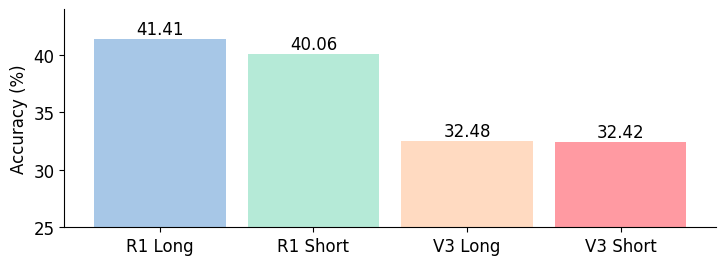

In [10]:
models = ['R1 Long', 'R1 Short', 'V3 Long', 'V3 Short']
plotter = MetricPlotter(bar_width = 0.3, annotation_digits=2, y_lim_lower = 25, y_lim_upper=44, figure_height=3)
plotter.group_gap = 0.05
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#A7C7E7', '#B5EAD7', '#FFDAC1', '#FF9AA2', '#C7CEEA']
# plotter.rotation = 30
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 12
plotter.y_label_fontsize=12
plotter.x_tick_fontsize=12
plotter.y_tick_fontsize=12
plotter.barplot(models ,np.array(accuracies), 
             x_label="", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )

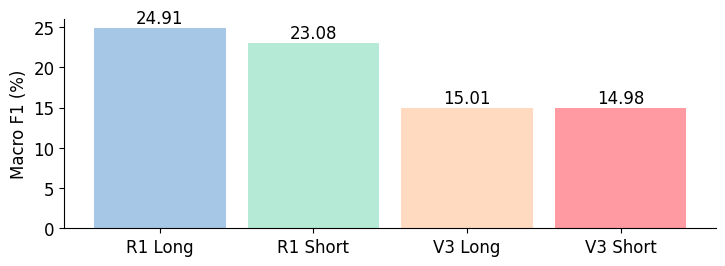

In [ ]:
models = ['R1 Long', 'R1 Short', 'V3 Long', 'V3 Short']
macro_f1 = [float(df.iloc[-3,2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
plotter = MetricPlotter(bar_width = 0.3, annotation_digits=2, y_lim_lower = 0, y_lim_upper=26, figure_height=3)
plotter.group_gap = 0.05
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#A7C7E7', '#B5EAD7', '#FFDAC1', '#FF9AA2', '#C7CEEA']
# plotter.rotation = 30
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 12
plotter.y_label_fontsize=12
plotter.x_tick_fontsize=12
plotter.y_tick_fontsize=12
plotter.barplot(models ,np.array(macro_f1), 
             x_label="", y_label="Macro F1")

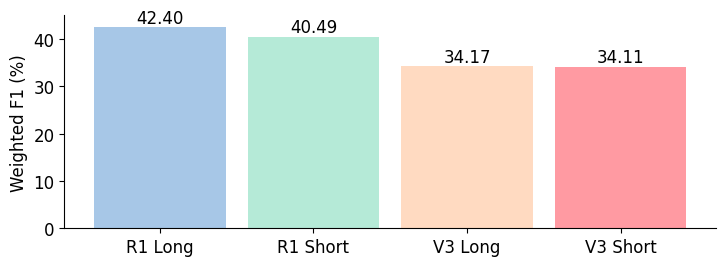

In [16]:
models = ['R1 Long', 'R1 Short', 'V3 Long', 'V3 Short']
weighted_f1 = [float(df.iloc[-2,2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
plotter = MetricPlotter(bar_width = 0.3, annotation_digits=2, y_lim_lower = 0, y_lim_upper=45, figure_height=3)
plotter.group_gap = 0.05
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#A7C7E7', '#B5EAD7', '#FFDAC1', '#FF9AA2', '#C7CEEA']
# plotter.rotation = 30
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 12
plotter.y_label_fontsize=12
plotter.x_tick_fontsize=12
plotter.y_tick_fontsize=12
plotter.barplot(models ,np.array(weighted_f1), 
             x_label="", y_label="Weighted F1", 
             # title="LLMs' Performance for Clusters"
             )

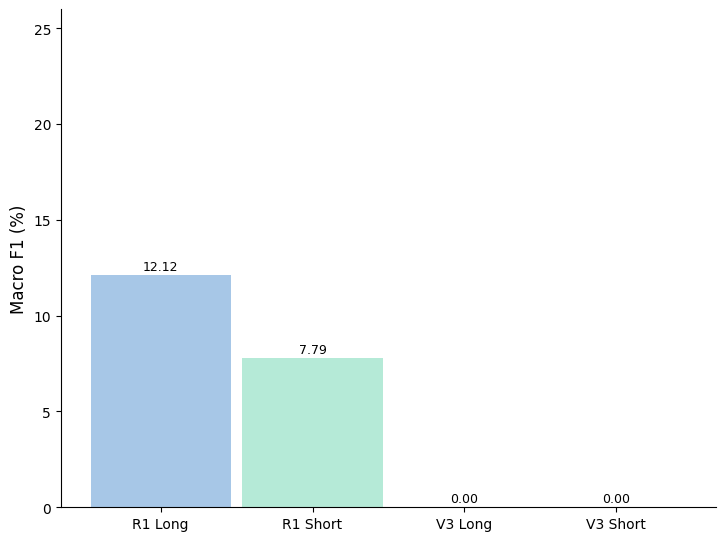

In [12]:
median_f1 = [float(df.iloc[-1,2]) for df in [r1_0528_long, r1_0528, v3_long, v3]]
plotter = MetricPlotter(bar_width = 0.6, annotation_digits=2, y_lim_lower = 0, y_lim_upper=26)
plotter.group_gap = 0.05
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#A7C7E7', '#B5EAD7', '#FFDAC1', '#FF9AA2', '#C7CEEA']
# plotter.rotation = 30
plotter.barplot(models ,np.array(median_f1), 
             x_label="", y_label="Macro F1", 
             # title="LLMs' Performance for Clusters"
             )

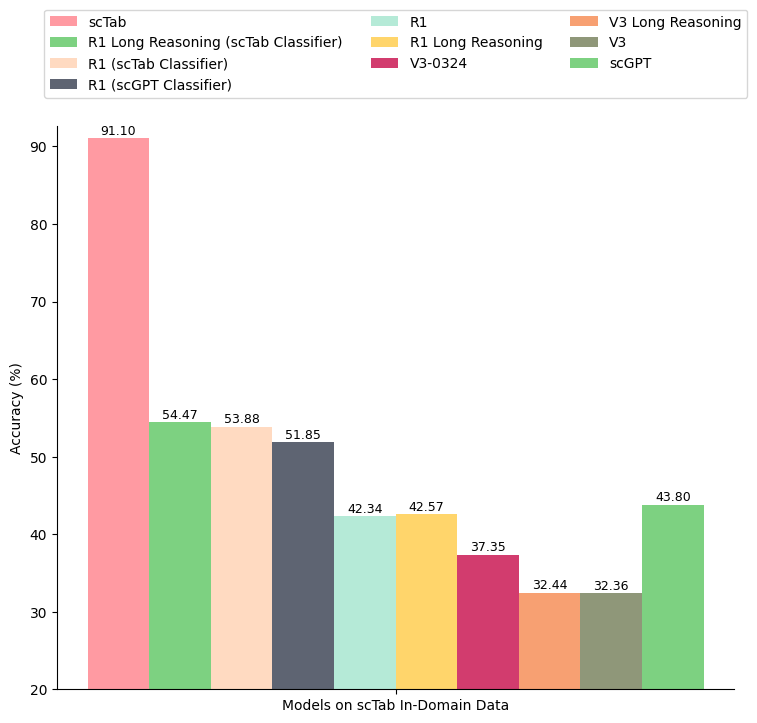

In [ ]:
# removed plot, models on in-domain scTab validation dataset

plotter = MetricPlotter(bar_width = 0.6, annotation_digits=2, 
                        y_lim_lower = 20, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.figure_height = 8
plotter.group_gap = 0
plotter.text_margin = 0.001
# plotter.colors = ['#FF9AA2', '#7DD181', '#FFDAC1' ,'#5E6472', '#9D84C8','#B5EAD7','#FFD56B', '#8AC6D1', '#D4A017', '#D23C6E', '#F7A072', '#8F9779', '#7DD181', '#799FCB',  '#C3CBD5']
plotter.colors = ['#FF9AA2', '#7DD181', '#FFDAC1' ,'#5E6472','#B5EAD7','#FFD56B', '#D23C6E', '#F7A072', '#8F9779', '#7DD181', '#799FCB',  '#C3CBD5', '#9D84C8']

plotter.group_barplot(['Models on scTab In-Domain Data'],models,metrics = np.array([np.array(accuracies)]).T, 
             x_label="", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )

In [7]:
# sctab test datasets
file_paths_test = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/scTab/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/scGPT/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes_scGPTClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes_scTabClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/scTab_10k_test/responses/long_prompt_r1_0528/500genes/results.csv'
]
# cellxgene 8 datasets
file_paths_8d = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scTab/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scGPT/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1/100genes_scGPTClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1/100genes_scTabClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1/100genes/results.csv'
]
file_paths_random = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scTab/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scGPT/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/short_prompt_r1/100genes_scTabClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/short_prompt_r1/100genes/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/short_prompt_r1/100genes_scGPTClassifier/results.csv',
]


In [8]:
# cellxgene random sampled data
sctab, scgpt, r1_scgpt_cls, r1_sctab_cls, r1 = (pd.read_csv(file) for file in file_paths_test)
sctab_8d, scgpt_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, r1_8d = (pd.read_csv(file) for file in file_paths_8d)
# cellxgene random sampled data
sctab_random, scgpt_random,r1_sctab_cls_random, r1_random, r1_scgpt_cls_random = (pd.read_csv(file) for file in file_paths_random)

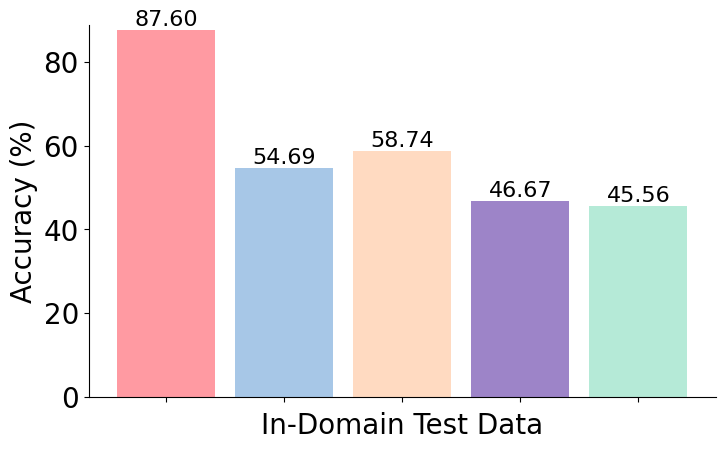

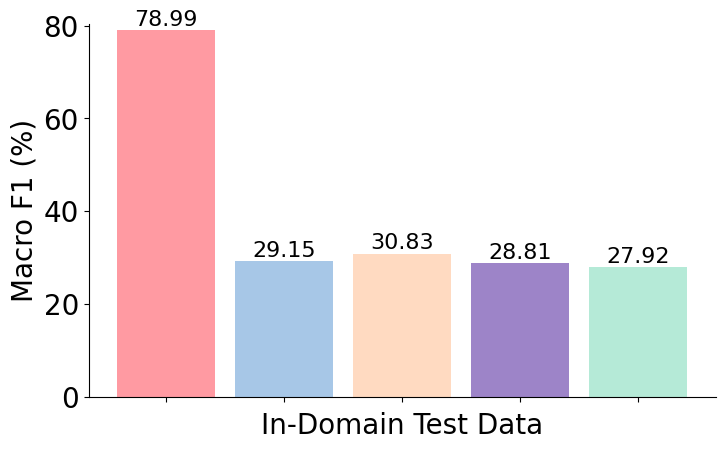

In [10]:
# 3D, models on in-domain scTab test dataset
accuracies = [float(df.iloc[-4,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1]]
models = ['']*5
plotter = MetricPlotter(bar_width = 0.25, annotation_digits=2, y_lim_lower = 0)
plotter.group_gap = 0.05
plotter.figure_height = 5
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7']
# plotter.rotation = 30
plotter.bar_fontsize = 16
plotter.x_label_fontsize = 20
plotter.y_label_fontsize=20
plotter.x_tick_fontsize=20
plotter.y_tick_fontsize=20
plotter.barplot(models ,np.array(accuracies), 
             x_label="In-Domain Test Data", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )


Macro_F1 = [float(df.iloc[-3,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1]]
models = ['']*5
plotter = MetricPlotter(bar_width = 0.25, annotation_digits=2, y_lim_lower = 0)
plotter.group_gap = 0.05
plotter.figure_height = 5
plotter.text_margin = 0.001
plotter.display_axes_borders='xy'
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7']
# plotter.rotation = 30
plotter.bar_fontsize = 16
plotter.x_label_fontsize = 20
plotter.y_label_fontsize=20
plotter.x_tick_fontsize=20
plotter.y_tick_fontsize=20
plotter.barplot(models ,np.array(Macro_F1), 
             x_label="In-Domain Test Data", y_label="Macro F1", 
             # title="LLMs' Performance for Clusters"
             )
# 1 5.57 3.77
# 1 5.57 4.77

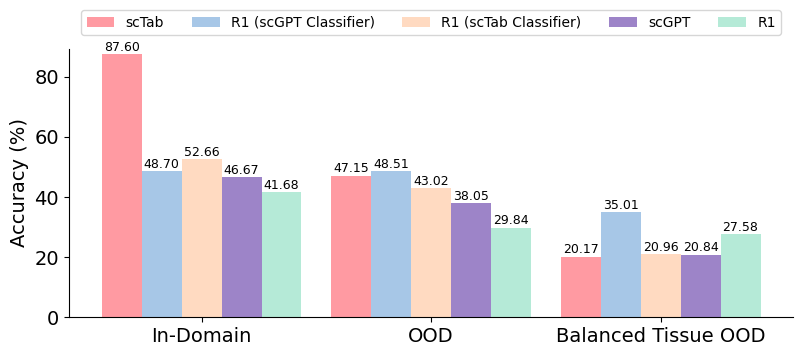

In [ ]:
# removed plot, overall in-domain and ood
multidata_accuracies = [
    [float(df.iloc[-4,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1]],
    [float(df.iloc[-4,2]) for df in [sctab_random, r1_scgpt_cls_random, r1_sctab_cls_random, scgpt_random, r1_random]],
    [float(df.iloc[-4,2]) for df in [sctab_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, scgpt_8d, r1_8d]]
]

datasets = ['In-Domain', 'OOD', 'Balanced Tissue OOD']
models = ['scTab', 'R1 (scGPT Classifier)', 'R1 (scTab Classifier)', 'scGPT', 'R1']

plotter = MetricPlotter(bar_width = 0.4, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.figure_height = 4
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.3
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
plotter.group_barplot(datasets,models,metrics = np.array(multidata_accuracies).T, 
             x_label="", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )

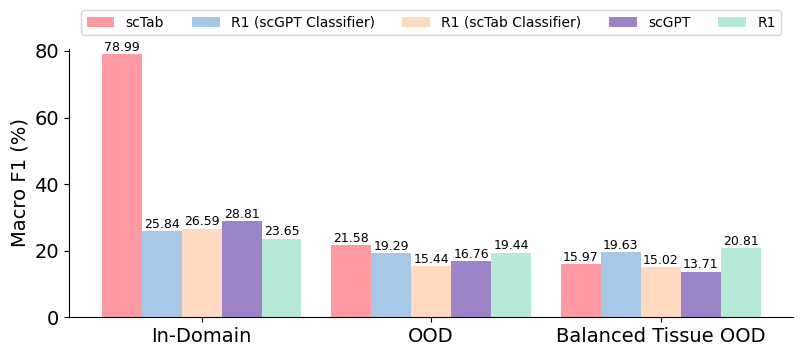

In [ ]:
# removed plot
macro_f1 = [
    [float(df.iloc[-3,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1]],
    [float(df.iloc[-3,2]) for df in [sctab_random, r1_scgpt_cls_random, r1_sctab_cls_random, scgpt_random, r1_random]],
    [float(df.iloc[-3,2]) for df in [sctab_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, scgpt_8d, r1_8d]]
]

datasets = ['In-Domain', 'OOD', 'Balanced Tissue OOD']
models = ['scTab', 'R1 (scGPT Classifier)', 'R1 (scTab Classifier)', 'scGPT', 'R1']

plotter = MetricPlotter(bar_width = 0.4, annotation_digits=2, 
                        y_lim_lower = 0
                        )
plotter.figure_height = 4
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.3
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
plotter.group_barplot(datasets,models,metrics = np.array(macro_f1).T, 
             x_label="", y_label="Macro F1", 
             # title="LLMs' Performance for Clusters"
             )

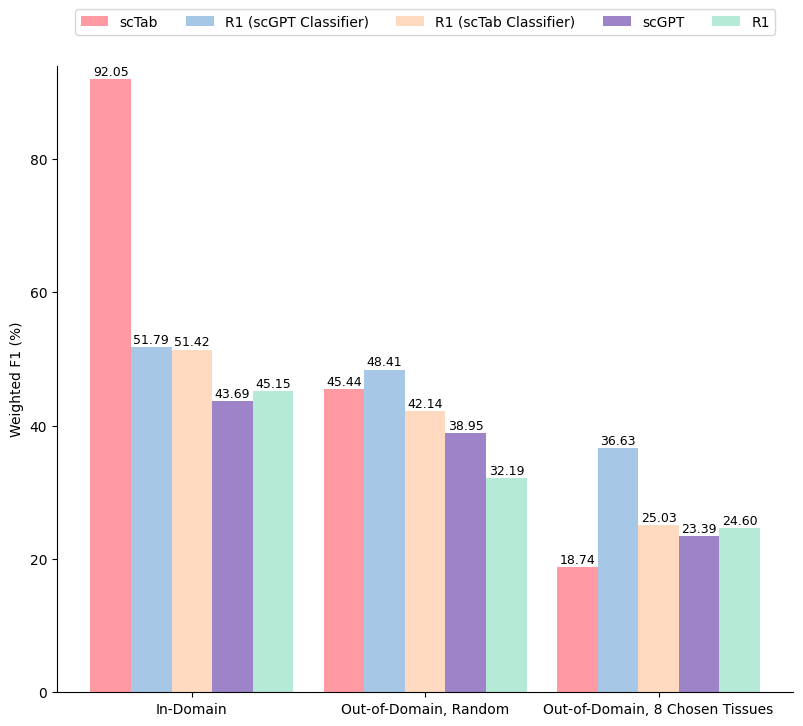

In [ ]:
# removed plot
weighted_f1 = [
    [float(df.iloc[-2,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1]],
    [float(df.iloc[-2,2]) for df in [sctab_random, r1_scgpt_cls_random, r1_sctab_cls_random, scgpt_random, r1_random]],
    [float(df.iloc[-2,2]) for df in [sctab_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, scgpt_8d, r1_8d]]
]

datasets = ['In-Domain', 'Out-of-Domain, Random', 'Out-of-Domain, 8 Chosen Tissues']
models = ['scTab', 'R1 (scGPT Classifier)', 'R1 (scTab Classifier)', 'scGPT', 'R1']

plotter = MetricPlotter(bar_width = 0.4, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.figure_height = 8
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.3
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.group_barplot(datasets,models,metrics = np.array(weighted_f1).T, 
             x_label="", y_label="Weighted F1", 
             # title="LLMs' Performance for Clusters"
             )

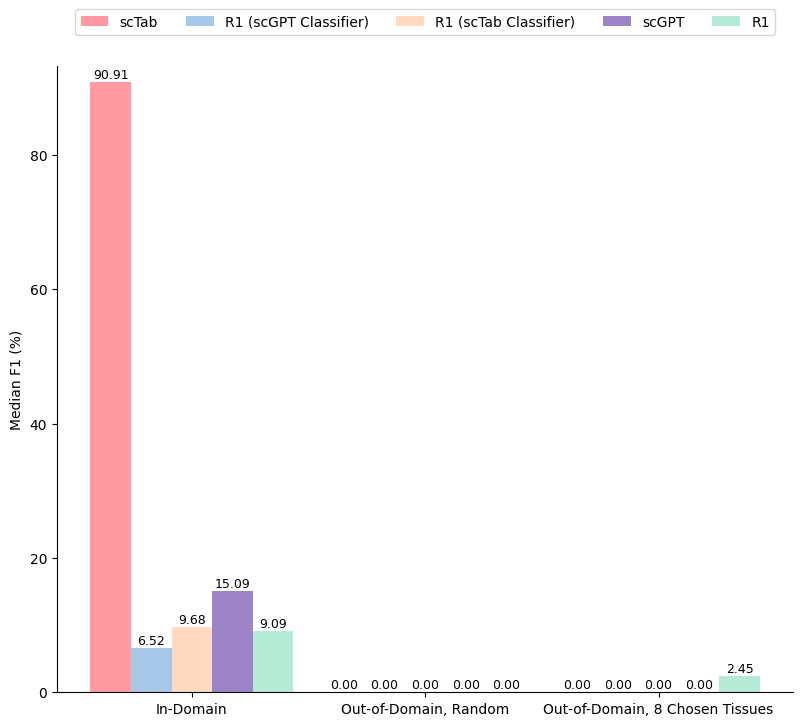

In [ ]:
# removed plot
median_f1 = [
    [float(df.iloc[-1,2]) for df in [sctab, r1_scgpt_cls, r1_sctab_cls, scgpt, r1]],
    [float(df.iloc[-1,2]) for df in [sctab_random, r1_scgpt_cls_random, r1_sctab_cls_random, scgpt_random, r1_random]],
    [float(df.iloc[-1,2]) for df in [sctab_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, scgpt_8d, r1_8d]]
]

datasets = ['In-Domain', 'Out-of-Domain, Random', 'Out-of-Domain, 8 Chosen Tissues']
models = ['scTab', 'R1 (scGPT Classifier)', 'R1 (scTab Classifier)', 'scGPT', 'R1']

plotter = MetricPlotter(bar_width = 0.4, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.figure_height = 8
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.3
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.group_barplot(datasets,models,metrics = np.array(median_f1).T, 
             x_label="", y_label="Median F1", 
             # title="LLMs' Performance for Clusters"
             )